In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [133]:
currentDirectory = Path.cwd()
dataFolder = currentDirectory.parent / "data"

def calculateSharpe(dailyReturns):
    dailyReturns = np.array([pair[1] for pair in dailyReturns])
    riskFreeRateAnnual = 0.0  
    riskFreeRateDaily = (1+riskFreeRateAnnual)**(1/252)-1

    excessReturns = dailyReturns - riskFreeRateDaily 
    meanExcess = np.mean(excessReturns)

    returnsStDev = np.std(excessReturns)

    return (meanExcess / returnsStDev) * np.sqrt(252)

# 1. reads ticker data from parquet files in data folder into a pandas dataframe
# 2. calculates a 20 day simple moving average (SMA) and standard deviation (SD) for each timestep and adds a column to the DF
# 3. removes rows with no SMA or SD
# 4. calculates the signals and adds a column to dataframe. buy if 1, sell if -1, hold if 0
#       buy when close price is less than two standard deviations from the SMA
#       Sell when close price is greater than two standard deviations from the SMA
# 5. Return dataframe with additional SMA, SD, and Signal columns
# NOTES: I am using a 20 day SMA and SD because I had 90% loss when using 50 day.
#        20 day results in a 300% gain.
#        This strategy is very unlikely to work in the real world. I have not (yet) considered all the biases, slippage, transaction costs, etc. 
def calculateSignals(ticker):
    # 1.
    df = pd.read_parquet(dataFolder / f"{ticker}_data.parquet") 
    
    print("Ticker: ", ticker)
    # 2.
    #20 day moving average.
    df['SMA'] = df['Close'].rolling(window=20).mean().fillna(0)
    df = df[df['SMA'] != 0]
    #20 day moving standard deviation
    df['SD'] = df['Close'].rolling(window=20).std().fillna(0)

    # 3. 
    # Don't want columns that don't have any indicators
    df = df[df['SMA'] != 0]
    df = df[df['SD'] != 0]

    # 4. 
    # Buy = 1, Sell = -1, Hold = 0
    signalConditions = [
        (df['Close'] <= (df['SMA']-(2*df['SD']))), # Buy cond.
        (df['Close'] >= (df['SMA']+(2*df['SD'])))] # Sell cond.
    df['Signal'] = np.select(signalConditions, [1,-1], default=0)

    # 5.
    return df


# Creates a plot of the ticker price and marks each spot where a trade was made
# Had AI do the plotting because my matplotlib skills are rusty and I don't think its very important to the logic
def plotTrades(trades, tickerData, ticker):
    # 1. Set the figure size for better visibility
    plt.figure(figsize=(14, 7))

    # 2. Plot the Close Price
    # close price is autoadjusted so don't need to worry about that
    plt.plot(tickerData.index, tickerData['Close'], label='Close Price', color='blue', alpha=0.8)

    # 3. Plot the Buy Signals
    # Plot green points at Buy signal, Red at Sell
    buys = trades[trades['Signal'] == 1]
    sells = trades[trades['Signal'] == -1]
    plt.scatter(buys.index, buys['Close'], label='Buy Signal', marker='^', color='green', s=100)
    plt.scatter(sells.index, sells['Close'], label='Sell Signal', marker='^', color='red', s=100)

    # 4. Formatting
    plt.title(ticker + ' Adj. Close with Buy Signals')
    plt.xlabel('Date / Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

def plotEquity(dailyReturns):
    equityList = [pair[0] for pair in dailyReturns]
    timeSteps = range(len(equityList))

    plt.figure(figsize=(14,7))
    plt.plot(timeSteps, equityList, color='b', label="Total Equity")

    plt.grid(True, linestyle='--', alpha=0.6)

    plt.show()


def test_sharpe_logic():
    # Setup: 1% daily return, 2% daily volatility
    # Risk free rate set to 0 for simplicity in this test
    mock_returns = np.random.normal(0.01, 0.02, 1000)
    
    # Manually calculate expected
    mean_excess = np.mean(mock_returns) # ~0.01
    std_dev = np.std(mock_returns)      # ~0.02
    expected_annual = (mean_excess / std_dev) * np.sqrt(252)
    
    # Run your function (wrapped for the test)
    # Note: Ensure your function handles the riskFreeRateAnnual correctly
    actual = calculateSharpe([(None, r) for r in mock_returns])
    
    print(f"Manual Calculation: {expected_annual:.4f}")
    print(f"Function Result: {actual:.4f}")

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN']
Ticker:  MMM


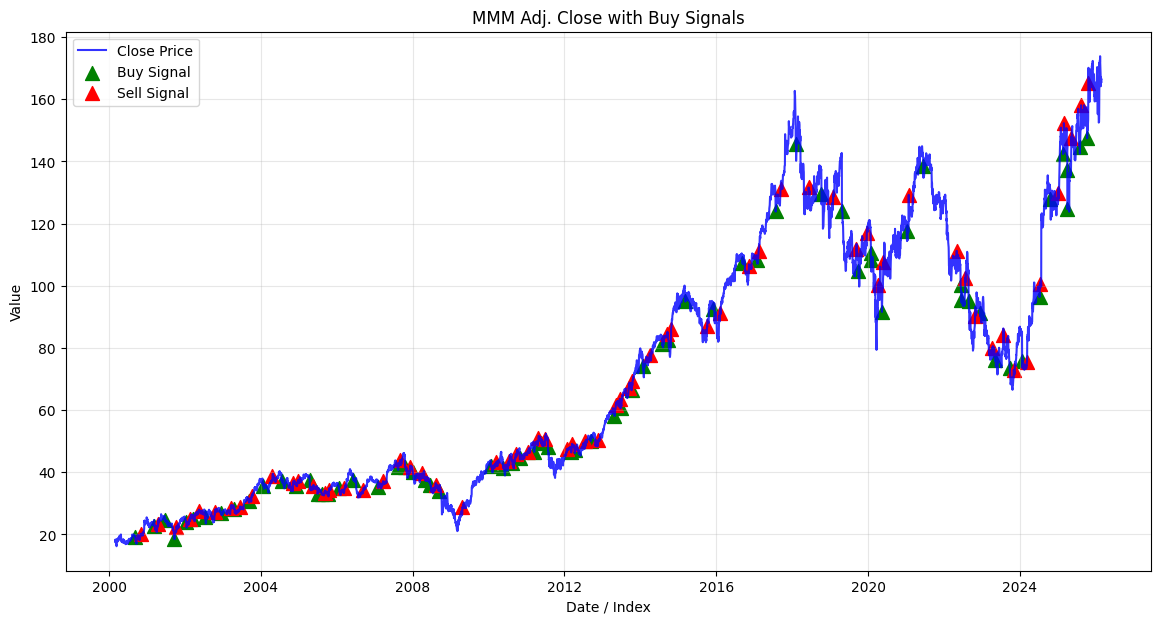

Resulting Capital: $30340.6
Profit: $20340.6
Sharpe Ratio: 0.32
Avg Daily Return: 0.0002366688451529197


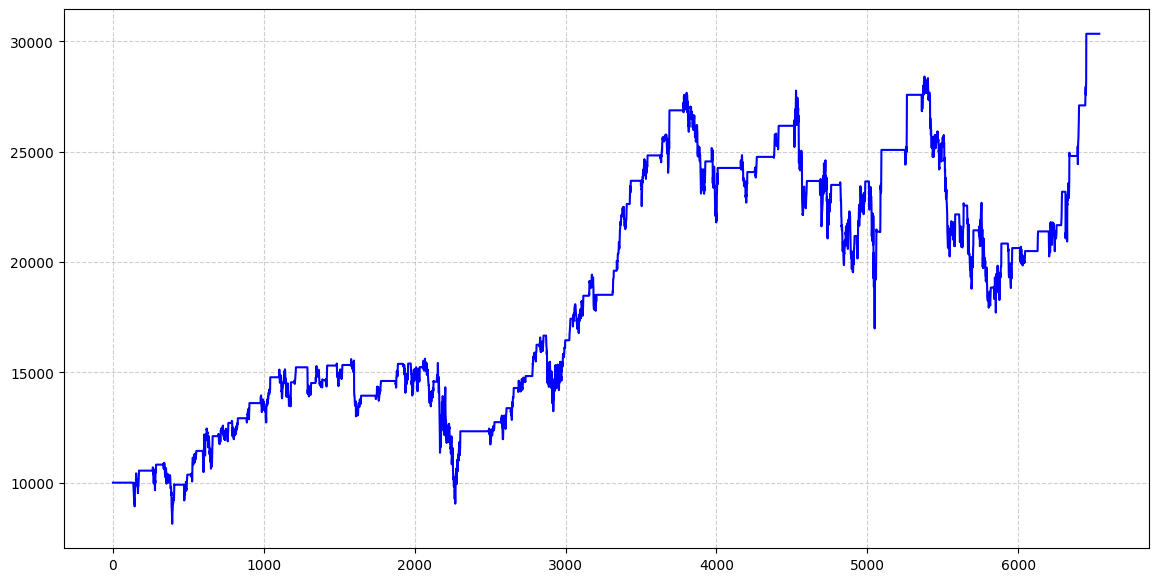

Manual Calculation: 7.0328
Function Result: 7.0328


In [ ]:


# get ticker list
tickers = pd.read_csv(dataFolder / 'ticker_list.csv')
tickers = tickers['Symbol'].tolist()
testDate = '1/1/2020'
print(tickers)
tickerData = calculateSignals(tickers[0])


capital = 10000
actualTrades = pd.DataFrame() # I want to keep track of when trades are actually made so I can plot it
positions = [] # [numShares, price].
dailyReturns = [[capital, 0]] # Initial total equity is capital, and initial daily return is 0. Need to have these so I can do daily return calculations

# each day is a time step
for timestep in range(len(tickerData)):
    price = tickerData.iloc[timestep]['Close']
    signal = tickerData.iloc[timestep]['Signal']

    totalEquity = capital+sum(n*price for n,_ in positions)
    dailyReturn = ((totalEquity - dailyReturns[-1][0]) / dailyReturns[-1][0])

    dailyReturns.append([totalEquity, dailyReturn])

    
    if signal == 1 and capital != 0: # Can't buy even if we got a signal if capital is 0
        # Currently this is utilizing 100% capital when buying, and selling all shares when selling
        # Not ideal but I am just testing and learning
        numSharesToBuy = capital // price
        capital -= numSharesToBuy*price

        if numSharesToBuy: # We don't want to add a position if we aren't actually buying anything
            #print("buying", numSharesToBuy, "shares at", price)
            positions.append([numSharesToBuy, price])
            actualTrades = pd.concat([actualTrades, tickerData.iloc[[timestep]]])
            
    elif signal == -1 and positions:
        #print("Selling", positions, "shares at", price)
        capital += positions[0][0] * price
        positions = []
        actualTrades = pd.concat([actualTrades, tickerData.iloc[[timestep]]])

plotTrades(actualTrades, tickerData, tickers[0])
print("Resulting Equity: $" + str(np.round(capital, decimals=2)))
print("Profit: $" + str(np.round(capital-10000, decimals=2)))
print("Sharpe Ratio:", np.round(calculateSharpe(dailyReturns), decimals=2))
print("Avg Daily Return:", sum(n for _,n in dailyReturns)/len(dailyReturns))
plotEquity(dailyReturns)
test_sharpe_logic()


